## Multivariate Forecasting

with:- 

feature columns, 
lag features, 
rolling features, 
time features

and train:

# XGBoost

# Step For Random Forest Model to train and test data.
STEP 1 → Understand & Load Data

STEP 2 → Clean Data

STEP 3 → Feature Engineering

STEP 4 → Train/Test Split

STEP 5 → Train Random Forest

STEP 6 → Predict

STEP 7 → Accuracy Check

STEP 8 → Feature Importance

STEP 9 → Future Forecasting

STEP 10 → Advanced Tuning

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [2]:
# Data Loading 
raw_data = pd.read_csv('Energy_Dataset_ML.csv')
print(raw_data.shape)
raw_data.head()


(40952, 23)


,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target
0,04/10/2024 12:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,101.537338,526.225403,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5
1,04/10/2024 12:15,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,87.574669,512.467468,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0
2,04/10/2024 12:30,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,67.657333,523.296082,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5
3,04/10/2024 12:45,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,94.453339,543.406433,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5
4,04/10/2024 13:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,96.096001,540.641663,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0


In [3]:
print(raw_data.columns)

# data types Checking
raw_data.info()

Index(['Time', 'feature_01', 'feature_02', 'feature_03', 'feature_04',
       'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'target'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 40952 entries, 0 to 40951
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        40952 non-null  str    
 1   feature_01  40952 non-null  float64
 2   feature_02  40952 non-null  float64
 3   feature_03  40952 non-null  float64
 4   feature_04  40952 non-null  float64
 5   feature_05  40952 non-null  float64
 6   feature_06  40952 non-null  float64
 7   feature_07  40952 non-null  float64
 8   feature_08  40952 non-null  float64
 9   feature_09  40952 non-null  float64
 10  feature_10  40952 non-null  float64
 1

In [4]:
#checking for missing values
print(f"Total Missing Values:{raw_data.isnull().sum().sum()}\n \nEach Column:\n",raw_data.isnull().sum())

Total Missing Values:0
 
Each Column:
 Time          0
feature_01    0
feature_02    0
feature_03    0
feature_04    0
feature_05    0
feature_06    0
feature_07    0
feature_08    0
feature_09    0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
target        0
dtype: int64


In [5]:
# Data Set Understanding like mean max and STD , othere parameter of the data set
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_01,40952.0,3902.156877,3273.622302,0.000000,0.000000,5230.995606,7016.287231,7960.601074
feature_02,40952.0,296.077828,195.739376,0.000000,0.000000,405.170288,439.703980,710.868530
feature_03,40952.0,152.886518,116.615331,0.000000,0.000000,191.872559,240.944824,559.914551
feature_04,40952.0,64.260022,47.732196,0.010820,16.053831,80.515156,110.621801,135.429352
feature_05,40952.0,120.809209,119.596579,0.000000,0.000000,59.266491,244.118912,300.000000
feature_06,40952.0,511.819294,333.285731,0.000000,0.000000,729.599976,742.400024,934.349976
feature_07,40952.0,76.340845,44.186931,0.115741,75.317356,96.166355,102.415964,200.000000
feature_08,40952.0,93.026896,55.513266,0.000000,53.427717,118.309258,134.888348,157.527710
feature_09,40952.0,86.606632,42.391359,0.096078,95.215353,105.227501,110.339472,200.000000
feature_10,40952.0,674.524511,356.913081,0.000000,128.000000,880.259003,900.078735,929.809082


In [6]:
# Time is present in str format so we need to convert it into datetime format
raw_data['Time'] = pd.to_datetime(raw_data['Time'])
data = raw_data.sort_values('Time').reset_index(drop=True)
data.info()
data.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 40952 entries, 0 to 40951
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Time        40952 non-null  datetime64[us]
 1   feature_01  40952 non-null  float64       
 2   feature_02  40952 non-null  float64       
 3   feature_03  40952 non-null  float64       
 4   feature_04  40952 non-null  float64       
 5   feature_05  40952 non-null  float64       
 6   feature_06  40952 non-null  float64       
 7   feature_07  40952 non-null  float64       
 8   feature_08  40952 non-null  float64       
 9   feature_09  40952 non-null  float64       
 10  feature_10  40952 non-null  float64       
 11  feature_11  40952 non-null  float64       
 12  feature_12  40952 non-null  float64       
 13  feature_13  40952 non-null  float64       
 14  feature_14  40952 non-null  float64       
 15  feature_15  40952 non-null  float64       
 16  feature_16  40952 non-null  float

,count,mean,min,25%,50%,75%,max,std
Time,40952,2024-12-04 04:49:28.887966,2024-04-10 12:00:00,2024-07-27 05:11:15,2024-12-14 12:52:30,2025-03-31 09:03:45,2025-07-31 23:00:00,NaN
feature_01,40952.0,3902.156877,0.0,0.0,5230.995606,7016.287231,7960.601074,3273.622302
feature_02,40952.0,296.077828,0.0,0.0,405.170288,439.70398,710.86853,195.739376
feature_03,40952.0,152.886518,0.0,0.0,191.872559,240.944824,559.914551,116.615331
feature_04,40952.0,64.260022,0.01082,16.053831,80.515156,110.621801,135.429352,47.732196
feature_05,40952.0,120.809209,0.0,0.0,59.266491,244.118912,300.0,119.596579
feature_06,40952.0,511.819294,0.0,0.0,729.599976,742.400024,934.349976,333.285731
feature_07,40952.0,76.340845,0.115741,75.317356,96.166355,102.415964,200.0,44.186931
feature_08,40952.0,93.026896,0.0,53.427717,118.309258,134.888348,157.52771,55.513266
feature_09,40952.0,86.606632,0.096078,95.215353,105.227501,110.339472,200.0,42.391359


In [7]:
# need to check Time range data Start and End time
print(f"Start Time: {data['Time'].min()}, End Time: {data['Time'].max()}")

Start Time: 2024-04-10 12:00:00, End Time: 2025-07-31 23:00:00


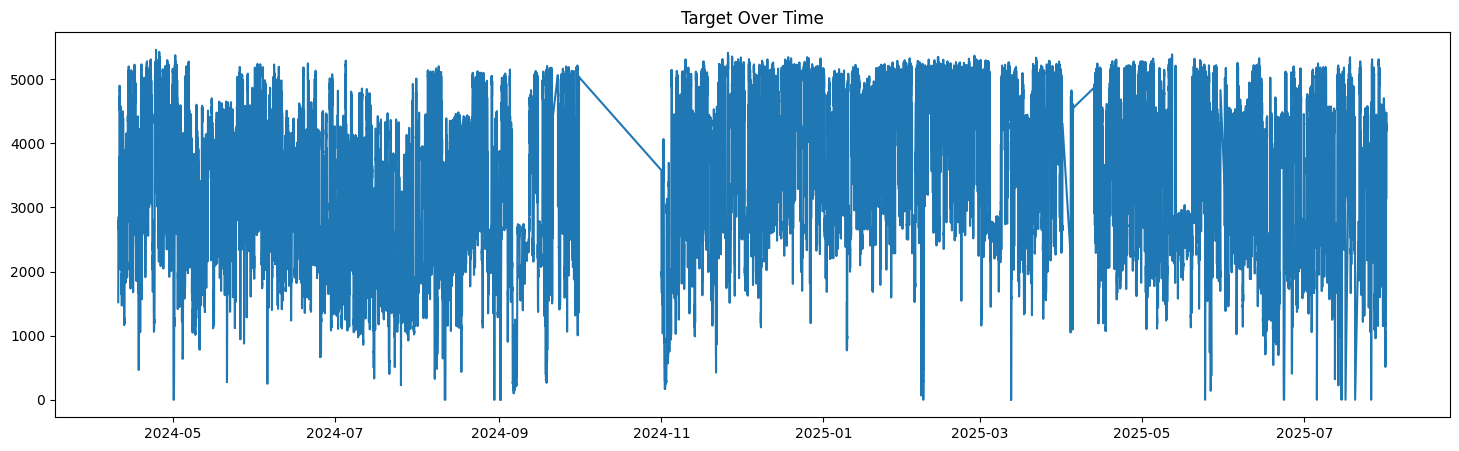

In [8]:
# Need to check Traget data from start to end time
plt.figure(figsize=(18,5))
plt.plot(data['Time'],data['target'])

plt.title("Target Over Time")

plt.show()

In [9]:
# Data is so cluter need to check what is the average use in that 1 day duration of 15min interval 
# Removing Noicy data taking average og 1 day rolling mean 24 * 4 = 96

# data['target_rollmean'] = data['target'].rolling(window=96).mean()
# data.head(100).T

# not in use for future also

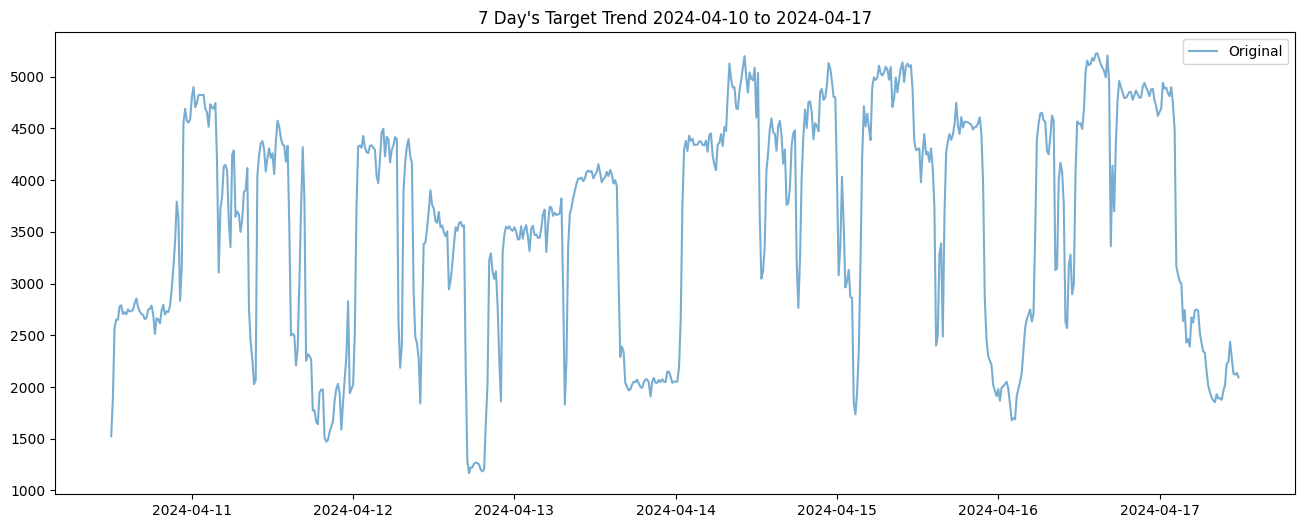

In [10]:
#//////cancel this step //// Need to Check the smoothed target trend using rolling mean for 1 week data

# need to zoom data till 7 day to check is every day data is same or not and also check the trend of the data

plt.figure(figsize=(16,6))

one_week = data[data['Time'] < data['Time'].min() + pd.Timedelta(days=7)]

plt.plot(one_week['Time'],one_week['target'],alpha=0.6,label='Original')
# plt.plot(one_week['Time'],one_week['target_rollmean'],linewidth=3,label='1-Day Rolling Mean')
# plt.plot(one_week['Time'],one_week['target'],marker='o',markersize=2)

plt.title("7 Day's Target Trend " + str(one_week['Time'].min().date()) + " to " + str(one_week['Time'].max().date()))
plt.legend()

plt.show()

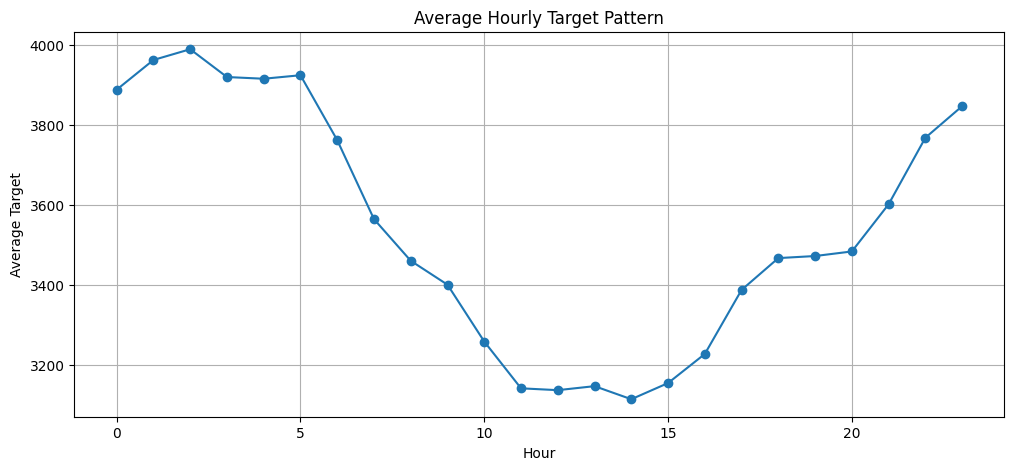

In [11]:
# Checking Hourly Seasonality patterns in the data

data['hour'] = data['Time'].dt.hour
hourly_pattern = (data.groupby('hour')['target'].mean())

plt.figure(figsize=(12,5))

plt.plot(hourly_pattern.index,hourly_pattern.values,marker='o')
plt.title("Average Hourly Target Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Target")

plt.grid(True)
plt.show()

# Hourly Trend Analysis

Hour Range	Typical Behavior

0–5	    High demand

6–10    Falling

11–15   Lowest demand

16–23   Rising again

This is the GENERAL daily cycle learned from ALL data.

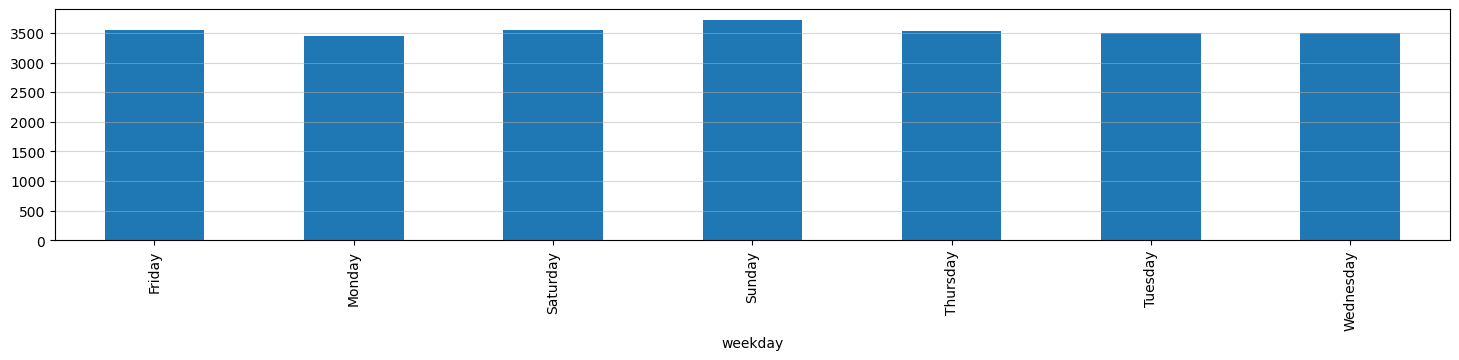

In [ ]:
# Adding the Weekly Seasonality pattern in the data

data['weekday'] = data['Time'].dt.day_name()
weekly_pattern = (data.groupby('weekday')['target'].mean())

weekly_pattern.plot(kind='bar', figsize=(18,3))

plt.grid(True,axis='y',alpha=0.5)

# Feature Engineering
We transform:

Raw Data	 -> Smart ML Features

Time	     -> hour

Time     	 -> day_of_week

Time	     -> month

Past target	 -> lag features

Recent trend -> rolling mean

Cyclic time  -> sin/cos encoding

In [13]:
data_RF = data.copy()
data_RF.head()

,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target,hour,weekday
0,2024-04-10 12:00:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5,12,Wednesday
1,2024-04-10 12:15:00,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0,12,Wednesday
2,2024-04-10 12:30:00,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5,12,Wednesday
3,2024-04-10 12:45:00,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5,12,Wednesday
4,2024-04-10 13:00:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0,13,Wednesday


In [14]:
#  Time Features

#hourly pattern [0-23]
data_RF['hour'] = data_RF['Time'].dt.hour

#weekly pattern [Monday=0, Tuesday=1, Wednesday=2, Thursday=3, Friday=4, Saturday=5, Sunday=6]
data_RF['day_of_week'] = data_RF['Time'].dt.dayofweek


#Day of Month pattern [1-31]
data_RF['day_of_month'] = data_RF['Time'].dt.day

#month pattern [1-12]
data_RF['month'] = data_RF['Time'].dt.month

#quarterly pattern [1-4]
data_RF['quarter'] = data_RF['Time'].dt.quarter

#yearly pattern [2024-2025]
data_RF['year'] = data_RF['Time'].dt.year

#is_weekend pattern [0 for weekday, 1 for weekend] [Monday - Saturday = 0, Sunday = 1 ]
data_RF['is_weekend'] = (data_RF['day_of_week'] >= 5).astype(int)




In [15]:
data_RF.head(5)

,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_21,target,hour,weekday,day_of_week,day_of_month,month,quarter,year,is_weekend
0,2024-04-10 12:00:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,728.515625,1522.5,12,Wednesday,2,10,4,2,2024,0
1,2024-04-10 12:15:00,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,776.747009,1895.0,12,Wednesday,2,10,4,2,2024,0
2,2024-04-10 12:30:00,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,748.914978,2572.5,12,Wednesday,2,10,4,2,2024,0
3,2024-04-10 12:45:00,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,775.173645,2652.5,12,Wednesday,2,10,4,2,2024,0
4,2024-04-10 13:00:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,789.008301,2650.0,13,Wednesday,2,10,4,2,2024,0


In [16]:
# Cyclic Features

#hour_sin
data_RF['hour_sin'] = np.sin(2 * np.pi * data_RF['hour'] / 24)

#hour_cos
data_RF['hour_cos'] = np.cos(2 * np.pi * data_RF['hour'] / 24)

data_RF.head().T

,0,1,2,3,4
Time,2024-04-10 12:00:00,2024-04-10 12:15:00,2024-04-10 12:30:00,2024-04-10 12:45:00,2024-04-10 13:00:00
feature_01,0.0,0.0,0.0,0.0,0.0
feature_02,0.0,0.0,0.0,0.0,0.0
feature_03,0.0,0.0,0.0,0.0,0.0
feature_04,119.290878,119.224632,119.294258,119.45182,119.407585
feature_05,0.0,0.0,0.0,0.0,0.0
feature_06,0.0,0.0,0.0,0.0,0.0
feature_07,108.502075,0.173611,100.112236,95.328934,85.291878
feature_08,134.461426,0.404006,109.55497,137.83876,144.616455
feature_09,100.306824,0.115741,0.115741,70.482636,90.254265


In [17]:
# Lag Features

# Lag 1
data_RF['target_lag_1'] = data_RF['target'].shift(1)

# Lag 2
data_RF['target_lag_2'] = data_RF['target'].shift(2)

#lag 3
data_RF['target_lag_3'] = data_RF['target'].shift(3)

#lag 4
data_RF['target_lag_4'] = data_RF['target'].shift(4)

# 1 Day Lag 15 min interval 24 * 4 = 96
data_RF['target_lag_96'] = data_RF['target'].shift(96)

#weekly lag 7 day lag 7 * 24 * 4 = 672
data_RF['target_lag_672'] = data_RF['target'].shift(672)

data_RF.head(5).T

,0,1,2,3,4
Time,2024-04-10 12:00:00,2024-04-10 12:15:00,2024-04-10 12:30:00,2024-04-10 12:45:00,2024-04-10 13:00:00
feature_01,0.0,0.0,0.0,0.0,0.0
feature_02,0.0,0.0,0.0,0.0,0.0
feature_03,0.0,0.0,0.0,0.0,0.0
feature_04,119.290878,119.224632,119.294258,119.45182,119.407585
feature_05,0.0,0.0,0.0,0.0,0.0
feature_06,0.0,0.0,0.0,0.0,0.0
feature_07,108.502075,0.173611,100.112236,95.328934,85.291878
feature_08,134.461426,0.404006,109.55497,137.83876,144.616455
feature_09,100.306824,0.115741,0.115741,70.482636,90.254265


In [18]:
# Rolling Mean Features

#Rolling Mean 3
data_RF['target_rollmean_3'] = data_RF['target'].rolling(window=3).mean()

#Rolling Mean 24
data_RF['target_rollmean_24'] = data_RF['target'].rolling(window=24).mean()

#Daily Rolling Mean
data_RF['target_rollmean_96'] = data_RF['target'].rolling(window=96).mean()

#Rolling Standard Deviation
data_RF['target_rollstd_96'] = data_RF['target'].rolling(window=96).std()

data_RF.head(5).T

,0,1,2,3,4
Time,2024-04-10 12:00:00,2024-04-10 12:15:00,2024-04-10 12:30:00,2024-04-10 12:45:00,2024-04-10 13:00:00
feature_01,0.0,0.0,0.0,0.0,0.0
feature_02,0.0,0.0,0.0,0.0,0.0
feature_03,0.0,0.0,0.0,0.0,0.0
feature_04,119.290878,119.224632,119.294258,119.45182,119.407585
feature_05,0.0,0.0,0.0,0.0,0.0
feature_06,0.0,0.0,0.0,0.0,0.0
feature_07,108.502075,0.173611,100.112236,95.328934,85.291878
feature_08,134.461426,0.404006,109.55497,137.83876,144.616455
feature_09,100.306824,0.115741,0.115741,70.482636,90.254265


In [19]:
#removing rows with NaN values created by lag and rolling features
data_RF = data_RF.dropna().reset_index(drop=True)
print(data_RF.shape)
data_RF.head(5).T

(40280, 43)


,0,1,2,3,4
Time,2024-04-17 12:00:00,2024-04-17 12:15:00,2024-04-17 12:30:00,2024-04-17 12:45:00,2024-04-17 13:00:00
feature_01,0.0,0.0,0.0,0.0,0.0
feature_02,0.0,0.0,0.0,0.0,0.0
feature_03,0.0,0.0,0.0,0.0,0.0
feature_04,111.167206,110.846565,110.736137,110.683296,110.694237
feature_05,0.0,0.0,0.0,0.0,0.0
feature_06,0.0,0.0,0.0,0.0,0.0
feature_07,106.308586,106.289238,106.341774,106.246117,108.454529
feature_08,140.340881,136.792465,146.285858,140.977936,143.348328
feature_09,200.0,200.0,200.0,200.0,0.115741


In [20]:
print(data_RF.columns)
print("NA values in data_RF:", data_RF.isnull().sum().sum())
data_RF.head(3).T

Index(['Time', 'feature_01', 'feature_02', 'feature_03', 'feature_04',
       'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'target', 'hour', 'weekday', 'day_of_week',
       'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'hour_sin',
       'hour_cos', 'target_lag_1', 'target_lag_2', 'target_lag_3',
       'target_lag_4', 'target_lag_96', 'target_lag_672', 'target_rollmean_3',
       'target_rollmean_24', 'target_rollmean_96', 'target_rollstd_96'],
      dtype='str')
NA values in data_RF: 0


,0,1,2
Time,2024-04-17 12:00:00,2024-04-17 12:15:00,2024-04-17 12:30:00
feature_01,0.0,0.0,0.0
feature_02,0.0,0.0,0.0
feature_03,0.0,0.0,0.0
feature_04,111.167206,110.846565,110.736137
feature_05,0.0,0.0,0.0
feature_06,0.0,0.0,0.0
feature_07,106.308586,106.289238,106.341774
feature_08,140.340881,136.792465,146.285858
feature_09,200.0,200.0,200.0


# model input now contains: -> Random Forest Training & Prediction

Information Type	     -> Example

Current sensor state	 -> feature_01

Current hour	         -> hour

Previous demand	         -> lag_1

Yesterday same time	     -> lag_96

Recent trend	         -> rolling mean

Volatility	             -> rolling std

In [21]:
#Training and Testing Data Split

X = data_RF.drop(['Time', 'target', 'weekday'],axis=1) # becaue Random Forest not consider the String data.
y = data_RF['target']
print(X.shape, y.shape)

(40280, 40) (40280,)


In [22]:
#Training  = 80% and Testing = 20%  Data Split 
split_index = int(len(data_RF) * 0.8)
X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

print(f"X_train: {X_train.shape} \n X_test : {X_test.shape} \n y_train: {y_train.shape} \n y_test : {y_test.shape}")


X_train: (32224, 40) 
 X_test : (8056, 40) 
 y_train: (32224,) 
 y_test : (8056,)


In [23]:
#Implementing XGBOOST Model

xgb_model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42
)

xgb_model.fit(X_train, y_train)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [24]:
#Testing the model
xgb_predictions = xgb_model.predict(X_test)


In [25]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

mask = y_test != 0

xgb_mape = mean_absolute_percentage_error(
    y_test[mask],
    xgb_predictions[mask]
) * 100


xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)



print("="*40)

print(f"XGBoost R2   : {xgb_r2:.4f}")

print(f"XGBoost MAE  : {xgb_mae:.2f}")

print(f"XGBoost RMSE : {xgb_rmse:.2f}")

print(f"XGBoost MAPE : {xgb_mape:.2f}%")

print("="*40)

XGBoost R2   : 0.9921
XGBoost MAE  : 63.12
XGBoost RMSE : 109.59
XGBoost MAPE : 2.54%


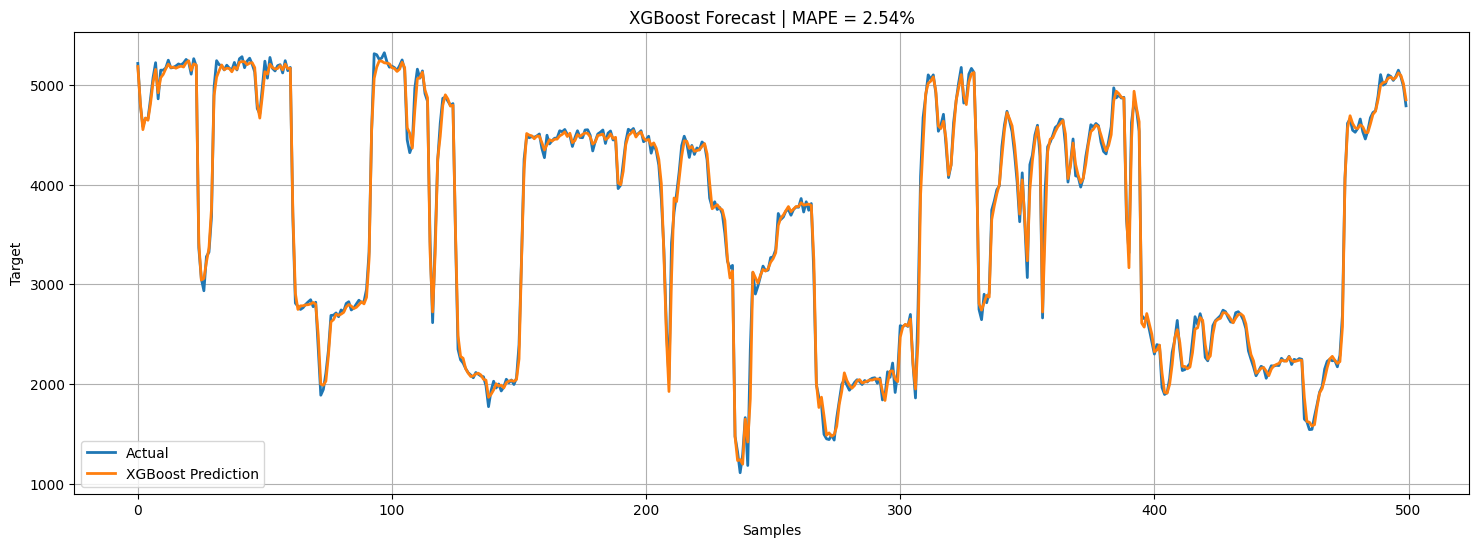

In [26]:
# Visualizing the Actual vs Predicted values for XGBoost Model

plt.figure(figsize=(18,6))

plt.plot(
    y_test.values[:500],
    label='Actual',
    linewidth=2
)

plt.plot(
    xgb_predictions[:500],
    label='XGBoost Prediction',
    linewidth=2
)

plt.title(
    f'XGBoost Forecast | MAPE = {xgb_mape:.2f}%'
)

plt.xlabel('Samples')

plt.ylabel('Target')

plt.legend()

plt.grid(True)

plt.show()

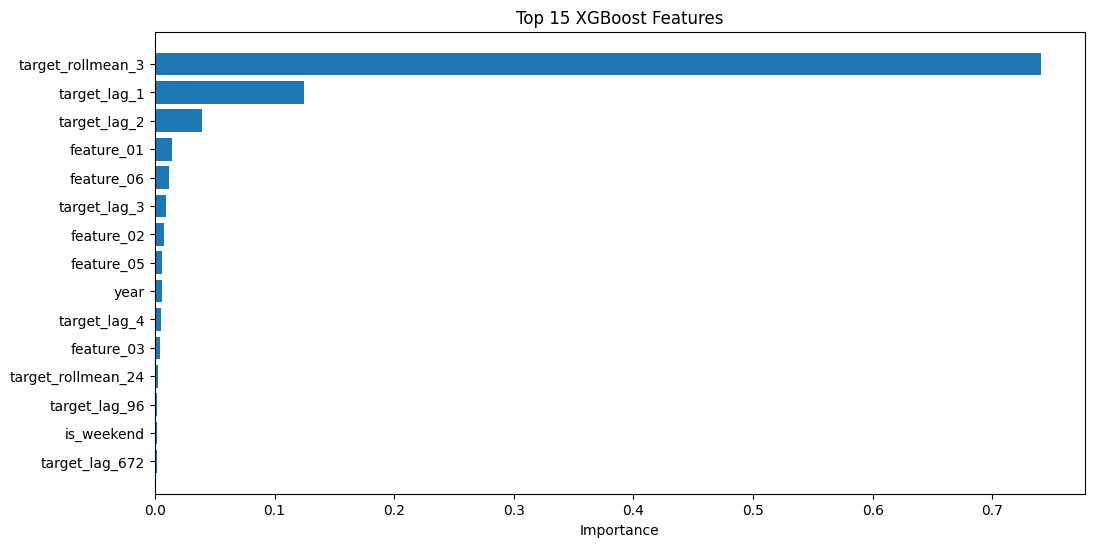

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,6))

plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)

plt.gca().invert_yaxis()

plt.title('Top 15 XGBoost Features')

plt.xlabel('Importance')

plt.show()

In [28]:
future_df = data_RF.copy()
history_targets = list(
    future_df['target'].values
)

last_row = future_df.iloc[-1:].copy()



In [29]:
future_predictions = []
future_times = []


for i in range(8):

    # Predict next value
    pred = xgb_model.predict(
        last_row.drop(
            ['Time', 'target', 'weekday'],
            axis=1
        )
    )[0]

    # Store prediction
    future_predictions.append(pred)

    # Add prediction into history
    history_targets.append(pred)

    # Next timestamp
    next_time = (
        pd.to_datetime(
            last_row['Time'].values[0]
        )
        + pd.Timedelta(minutes=15)
    )

    future_times.append(next_time)


    future_times.append(next_time)

    # Create next row
    new_row = last_row.copy()

    # Update target/time
    new_row['target'] = pred
    new_row['Time'] = next_time


    # =================================
    # Update Time Features
    # =================================

    new_row['hour'] = next_time.hour

    new_row['day_of_week'] = next_time.dayofweek

    new_row['day_of_month'] = next_time.day

    new_row['month'] = next_time.month

    new_row['quarter'] = next_time.quarter

    new_row['year'] = next_time.year

    new_row['is_weekend'] = int(
        next_time.dayofweek >= 5
    )


    # =================================
    # Cyclic Features
    # =================================

    new_row['hour_sin'] = np.sin(
        2 * np.pi * new_row['hour'] / 24
    )

    new_row['hour_cos'] = np.cos(
        2 * np.pi * new_row['hour'] / 24
    )


    # =================================
    # Lag Features
    # =================================

    new_row['target_lag_1'] = history_targets[-1]

    new_row['target_lag_2'] = history_targets[-2]

    new_row['target_lag_3'] = history_targets[-3]

    new_row['target_lag_4'] = history_targets[-4]

    new_row['target_lag_96'] = history_targets[-96]

    new_row['target_lag_672'] = history_targets[-672]

    # =================================
    # Rolling Features
    # =================================

    new_row['target_rollmean_3'] = np.mean(
        history_targets[-3:]
    )

    new_row['target_rollmean_24'] = np.mean(
        history_targets[-24:]
    )

    new_row['target_rollmean_96'] = np.mean(
        history_targets[-96:]
    )

    new_row['target_rollstd_96'] = np.std(
        history_targets[-96:]
    )

    # Move forward
    last_row = new_row.copy()

    



In [30]:
# ==========================================
# Create Future Forecast Table
# ==========================================

future_table = pd.DataFrame({
    'Future_Time': future_times,
    'Predicted_Target': future_predictions
})

print(future_table)

ValueError: All arrays must be of the same length